# 10 – Artificial Neural Network (MLP Classifier)

This notebook develops and evaluates baseline and hyperparameter-tuned Multi-Layer Perceptron (MLP) models for predicting Low, Medium and High waterborne disease risk.

In [1]:
# Import the libraries required for MLP Classifier model development

from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

In [2]:
# Define the locations of the prepared datasets, model files, and result files

DATA_PATH = Path("../data/model_input")
MODEL_PATH = Path("../models")
RESULTS_PATH = MODEL_PATH / "results"

MODEL_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print("Data folder:", DATA_PATH.resolve())
print("Model folder:", MODEL_PATH.resolve())
print("Results folder:", RESULTS_PATH.resolve())

Data folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\data\model_input
Model folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models
Results folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\results


In [3]:
# Load the prepared training and testing datasets

X_train = pd.read_csv(DATA_PATH / "X_train.csv")
X_test = pd.read_csv(DATA_PATH / "X_test.csv")

y_train = pd.read_csv(
    DATA_PATH / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    DATA_PATH / "y_test.csv"
).squeeze("columns")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 38)
X_test shape: (600, 38)
y_train shape: (2400,)
y_test shape: (600,)


In [4]:
# Load the saved feature scaler

scaler = joblib.load(
    MODEL_PATH / "scaler.pkl"
)

X_train_scaled = scaler.transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [5]:
# Create the baseline Multi-Layer Perceptron model

baseline_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2
)

print("Baseline MLP model created successfully.")

Baseline MLP model created successfully.


In [6]:
# Train the baseline MLP model

start_time = time.time()

baseline_mlp.fit(
    X_train_scaled,
    y_train
)

baseline_training_time = (
    time.time() - start_time
)

print(
    f"Training completed in "
    f"{baseline_training_time:.4f} seconds."
)

Training completed in 0.4745 seconds.


In [7]:
# Generate predictions using the trained baseline MLP model

baseline_train_predictions = baseline_mlp.predict(
    X_train_scaled
)

baseline_test_predictions = baseline_mlp.predict(
    X_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [8]:
# Calculate the evaluation metrics for the baseline MLP model

train_accuracy = accuracy_score(
    y_train,
    baseline_train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

precision = precision_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

generalisation_gap = (
    train_accuracy -
    test_accuracy
)

In [9]:
# Display the evaluation results of the baseline MLP model

print("=" * 50)
print("Baseline MLP Performance")
print("=" * 50)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-Score          : {f1:.4f}")
print(f"Training Time (s) : {baseline_training_time:.4f}")
print(f"Generalisation Gap: {generalisation_gap:.4f}")

Baseline MLP Performance
Training Accuracy : 0.9571
Testing Accuracy  : 0.8400
Precision         : 0.8419
Recall            : 0.8400
F1-Score          : 0.8408
Training Time (s) : 0.4745
Generalisation Gap: 0.1171


In [10]:
# Display the classification report

print("=" * 50)
print("Baseline MLP Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        baseline_test_predictions,
        digits=4,
        zero_division=0
    )
)

Baseline MLP Classification Report
              precision    recall  f1-score   support

        High     0.8838    0.8750    0.8794       200
         Low     0.8929    0.8663    0.8794       202
      Medium     0.7476    0.7778    0.7624       198

    accuracy                         0.8400       600
   macro avg     0.8414    0.8397    0.8404       600
weighted avg     0.8419    0.8400    0.8408       600



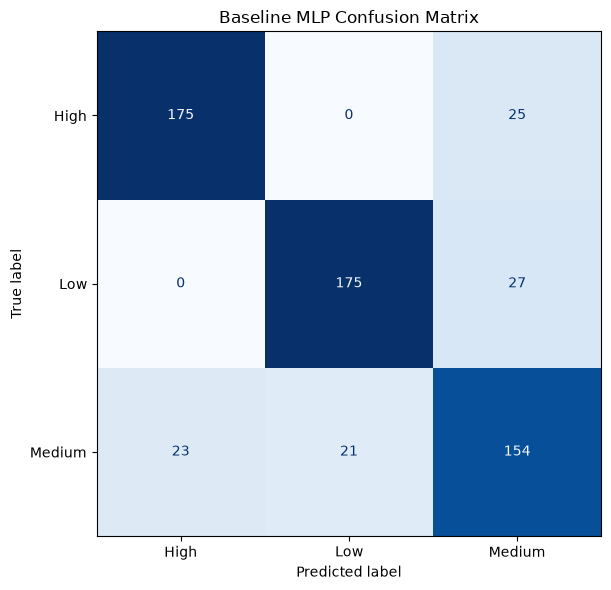

In [11]:
# Display the confusion matrix

baseline_confusion_matrix = confusion_matrix(
    y_test,
    baseline_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=baseline_confusion_matrix,
    display_labels=baseline_mlp.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Baseline MLP Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
# Define the hyperparameter values to be tested using GridSearchCV

parameter_grid = {
    "hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32),
        (128, 64)
    ],
    "activation": [
        "relu",
        "tanh"
    ],
    "learning_rate_init": [
        0.001,
        0.0005
    ],
    "alpha": [
        0.0001,
        0.001
    ]
}

print("Parameter grid created successfully.")

Parameter grid created successfully.


In [13]:
# Create the GridSearchCV object for MLP hyperparameter tuning

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=MLPClassifier(
        solver="adam",
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=42
    ),
    param_grid=parameter_grid,
    scoring="f1_weighted",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("GridSearchCV created successfully.")

GridSearchCV created successfully.


In [14]:
# Perform hyperparameter tuning using GridSearchCV

start_time = time.time()

grid_search.fit(
    X_train_scaled,
    y_train
)

tuning_time = time.time() - start_time

print(f"GridSearchCV completed in {tuning_time:.2f} seconds.")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
GridSearchCV completed in 12.02 seconds.


In [15]:
# Display the best hyperparameters identified by GridSearchCV

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}

Best Cross Validation Score:
0.8575


In [16]:
# Retrieve the best MLP model from GridSearchCV

tuned_mlp = grid_search.best_estimator_

print("Tuned MLP model created successfully.")

Tuned MLP model created successfully.


In [17]:
# Generate predictions using the tuned MLP model

tuned_train_predictions = tuned_mlp.predict(
    X_train_scaled
)

tuned_test_predictions = tuned_mlp.predict(
    X_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [18]:
# Calculate the evaluation metrics for the tuned MLP model

tuned_train_accuracy = accuracy_score(
    y_train,
    tuned_train_predictions
)

tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_generalisation_gap = (
    tuned_train_accuracy -
    tuned_test_accuracy
)

In [19]:
# Display the evaluation results of the tuned MLP model

print("=" * 50)
print("Tuned MLP Performance")
print("=" * 50)

print(f"Training Accuracy : {tuned_train_accuracy:.4f}")
print(f"Testing Accuracy  : {tuned_test_accuracy:.4f}")
print(f"Precision         : {tuned_precision:.4f}")
print(f"Recall            : {tuned_recall:.4f}")
print(f"F1-Score          : {tuned_f1:.4f}")
print(f"Training Time (s) : {tuning_time:.4f}")
print(f"Generalisation Gap: {tuned_generalisation_gap:.4f}")

Tuned MLP Performance
Training Accuracy : 0.8908
Testing Accuracy  : 0.8417
Precision         : 0.8435
Recall            : 0.8417
F1-Score          : 0.8423
Training Time (s) : 12.0184
Generalisation Gap: 0.0492


In [20]:
# Display the classification report for the tuned MLP model

print("=" * 50)
print("Tuned MLP Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        tuned_test_predictions,
        digits=4,
        zero_division=0
    )
)

Tuned MLP Classification Report
              precision    recall  f1-score   support

        High     0.8762    0.8850    0.8806       200
         Low     0.9016    0.8614    0.8810       202
      Medium     0.7512    0.7778    0.7643       198

    accuracy                         0.8417       600
   macro avg     0.8430    0.8414    0.8420       600
weighted avg     0.8435    0.8417    0.8423       600



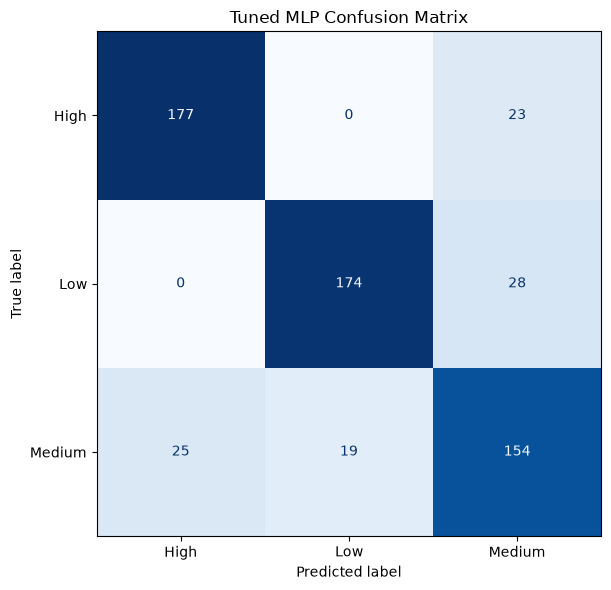

In [21]:
# Display the confusion matrix for the tuned MLP model

tuned_confusion_matrix = confusion_matrix(
    y_test,
    tuned_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_confusion_matrix,
    display_labels=tuned_mlp.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Tuned MLP Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
# Compare the baseline and tuned MLP models

comparison_results = pd.DataFrame({
    "Model": [
        "Baseline MLP",
        "Tuned MLP"
    ],
    "Training Accuracy": [
        train_accuracy,
        tuned_train_accuracy
    ],
    "Testing Accuracy": [
        test_accuracy,
        tuned_test_accuracy
    ],
    "Precision": [
        precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        tuned_recall
    ],
    "F1-Score": [
        f1,
        tuned_f1
    ],
    "Generalisation Gap": [
        generalisation_gap,
        tuned_generalisation_gap
    ]
})

comparison_results = comparison_results.round(4)

comparison_results

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Generalisation Gap
0,Baseline MLP,0.9571,0.8400,0.8419,0.8400,0.8408,0.1171
1,Tuned MLP,0.8908,0.8417,0.8435,0.8417,0.8423,0.0492


In [23]:
# Select the better MLP model based on the F1-Score

if tuned_f1 > f1:
    final_mlp_model = tuned_mlp
    selected_model = "Tuned MLP"
else:
    final_mlp_model = baseline_mlp
    selected_model = "Baseline MLP"

print("=" * 60)
print("Final MLP Model Selection")
print("=" * 60)

print(f"Selected Model : {selected_model}")

if selected_model == "Tuned MLP":
    print(f"Testing Accuracy : {tuned_test_accuracy:.4f}")
    print(f"F1-Score         : {tuned_f1:.4f}")
else:
    print(f"Testing Accuracy : {test_accuracy:.4f}")
    print(f"F1-Score         : {f1:.4f}")

print("\nReason:")
print("The tuned MLP achieved better overall performance while reducing overfitting.")

Final MLP Model Selection
Selected Model : Tuned MLP
Testing Accuracy : 0.8417
F1-Score         : 0.8423

Reason:
The tuned MLP achieved better overall performance while reducing overfitting.


In [24]:
# Save the baseline and tuned MLP models

joblib.dump(
    baseline_mlp,
    MODEL_PATH / "mlp_baseline.pkl"
)

joblib.dump(
    tuned_mlp,
    MODEL_PATH / "mlp_tuned.pkl"
)

print("MLP models saved successfully.")

MLP models saved successfully.


In [25]:
# Save the MLP comparison results

comparison_results.to_csv(
    RESULTS_PATH / "mlp_results.csv",
    index=False
)

print("Comparison results saved successfully.")

Comparison results saved successfully.


In [26]:
# Save the GridSearchCV results

grid_search_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_search_results.to_csv(
    RESULTS_PATH / "mlp_grid_search_results.csv",
    index=False
)

print("GridSearchCV results saved successfully.")

GridSearchCV results saved successfully.


In [27]:
# Save the best hyperparameters

joblib.dump(
    grid_search.best_params_,
    RESULTS_PATH / "mlp_best_parameters.pkl"
)

print("Best hyperparameters saved successfully.")

Best hyperparameters saved successfully.


In [28]:
# Verify that all MLP files were saved successfully

files_to_check = [
    MODEL_PATH / "mlp_baseline.pkl",
    MODEL_PATH / "mlp_tuned.pkl",
    RESULTS_PATH / "mlp_results.csv",
    RESULTS_PATH / "mlp_grid_search_results.csv",
    RESULTS_PATH / "mlp_best_parameters.pkl"
]

print("=" * 60)
print("Generated Files")
print("=" * 60)

for file in files_to_check:
    print(f"{file.name:<55} {file.exists()}")

Generated Files
mlp_baseline.pkl                                        True
mlp_tuned.pkl                                           True
mlp_results.csv                                         True
mlp_grid_search_results.csv                             True
mlp_best_parameters.pkl                                 True
